## 02 — Comparing the LOD Levels

The four output files exist. Now we load them and answer:

1. How do the files differ in size, feature count, and coordinate count?
2. What does each level look like on a real map?
3. At what zoom does each level look correct — and at what zoom does it start to look wrong?

This is the quality check before we build the switching logic.

## Load All Four Levels

In [5]:
import json
from pathlib import Path

filename = "railroads_coarse.geojson"
lod_candidates = [
    Path("../../data/lod"),
    Path("data/lod"),
    Path("Assignments_Completed/03-Data_Manager/data/lod"),
]

lod_dir = next((path for path in lod_candidates if (path / filename).exists()), None)
if lod_dir is None:
    matches = list(Path.cwd().rglob(filename))
    if not matches:
        raise FileNotFoundError(f"Could not find {filename} from {Path.cwd()}")
    lod_dir = matches[0].parent

data_dir = lod_dir.parent

lod_files = {
    "coarse":     "railroads_coarse.geojson",
    "medium":     "railroads_medium.geojson",
    "fine":       "railroads_fine.geojson",
    "extra_fine": "railroads_extra_fine.geojson",
}

lod_data = {}
for name, filename in lod_files.items():
    path = lod_dir / filename
    with open(path) as f:
        lod_data[name] = json.load(f)
    print(f"Loaded {name}: {len(lod_data[name]['features']):,} features")

Loaded coarse: 2,845 features
Loaded medium: 25,413 features
Loaded fine: 25,413 features
Loaded extra_fine: 25,413 features


## Summary Table — Size and Coordinate Count

In [6]:
print(f"{'Level':<12} {'Zoom':>6} {'Features':>10} {'Total pts':>12} {'File (MB)':>11}")
print("-" * 55)

zoom_ranges = {"coarse": "1-3", "medium": "4-6", "fine": "7-10", "extra_fine": "11+"}

for name, filename in lod_files.items():
    path = lod_dir / filename
    fc   = lod_data[name]
    n_features = len(fc["features"])
    total_pts  = sum(len(f["geometry"]["coordinates"]) for f in fc["features"])
    size_mb    = path.stat().st_size / 1_000_000
    zoom       = zoom_ranges[name]
    print(f"{name:<12} {zoom:>6} {n_features:>10,} {total_pts:>12,} {size_mb:>10.2f}")

# Also show the original for comparison
original_path = data_dir / "ne_10m_railroads.geojson"
with open(original_path) as f:
    original = json.load(f)
orig_pts  = sum(len(f["geometry"]["coordinates"]) for f in original["features"])
orig_size = original_path.stat().st_size / 1_000_000
print("-" * 55)
print(f"{'original':<12} {'all':>6} {len(original['features']):>10,} {orig_pts:>12,} {orig_size:>10.2f}")

Level          Zoom   Features    Total pts   File (MB)
-------------------------------------------------------
coarse          1-3      2,845        5,690       1.08
medium          4-6     25,413       55,513       9.66
fine           7-10     25,413      124,879      11.34
extra_fine      11+     25,413      441,871      18.98
-------------------------------------------------------
original        all     25,413    1,396,480      39.60


## Visual Comparison — One Level at a Time

Display each LOD level on a map. Pan and zoom to see where it starts to look correct and where it breaks down.

In [7]:
from ipyleaflet import Map, GeoJSON
import ipywidgets as widgets

# Change this to switch between levels: "coarse", "medium", "fine", "extra_fine"
level = "coarse"

level_zoom = {"coarse": 2, "medium": 4, "fine": 7, "extra_fine": 10}

m = Map(center=[20, 0], zoom=level_zoom[level])
layer = GeoJSON(
    data=lod_data[level],
    style={"color": "#cc3300", "weight": 1.5, "opacity": 0.8}
)
m.add(layer)

print(f"Showing: {level}  |  {len(lod_data[level]['features']):,} features")
m

Showing: coarse  |  2,845 features


Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

Try each level at its intended zoom range. Then deliberately zoom in too far on the coarse level — you should see the simplification artifacts clearly: straight lines where there should be curves.

## Side-by-Side Comparison — One Region

To see the difference sharply, let's crop to a small geographic area and display all four levels.

We filter to features whose bounding box falls within Europe (roughly).

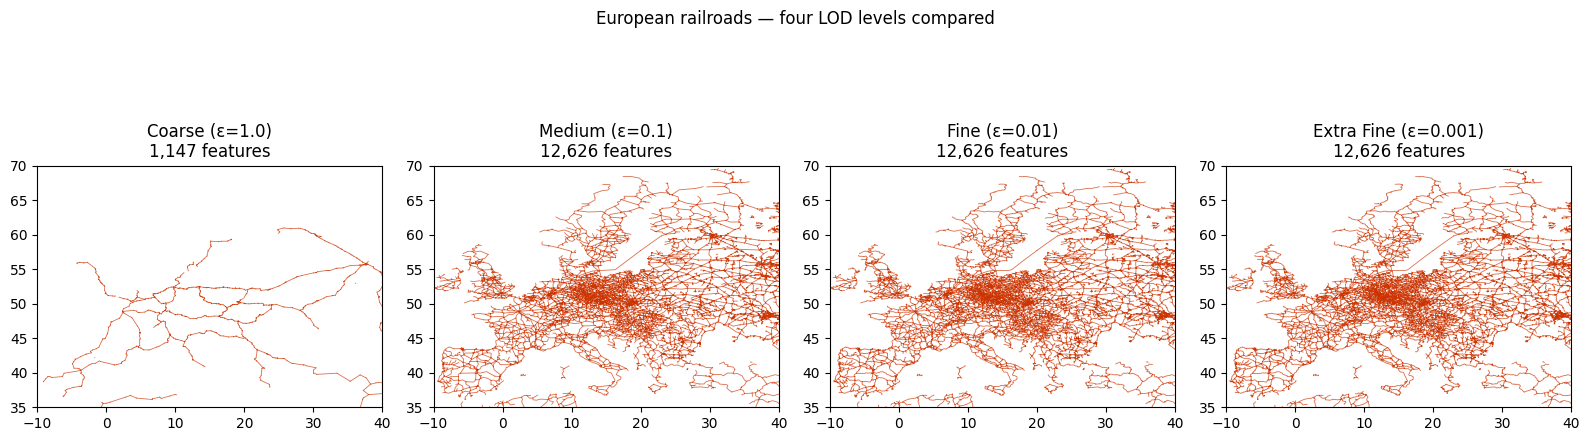

In [8]:
import matplotlib.pyplot as plt

# Europe bounding box [lon_min, lat_min, lon_max, lat_max]
europe = (-10, 35, 40, 70)

def coords_in_bbox(coords, bbox):
    lon_min, lat_min, lon_max, lat_max = bbox
    return any(
        lon_min <= c[0] <= lon_max and lat_min <= c[1] <= lat_max
        for c in coords
    )

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
titles = ["Coarse (ε=1.0)", "Medium (ε=0.1)", "Fine (ε=0.01)", "Extra Fine (ε=0.001)"]

for ax, (name, _), title in zip(axes, lod_files.items(), titles):
    europe_features = [
        f for f in lod_data[name]["features"]
        if coords_in_bbox(f["geometry"]["coordinates"], europe)
    ]
    for f in europe_features:
        xs = [c[0] for c in f["geometry"]["coordinates"]]
        ys = [c[1] for c in f["geometry"]["coordinates"]]
        ax.plot(xs, ys, '-', color='#cc3300', linewidth=0.6, alpha=0.7)
    ax.set_xlim(europe[0], europe[2])
    ax.set_ylim(europe[1], europe[3])
    ax.set_title(f"{title}\n{len(europe_features):,} features")
    ax.set_aspect('equal')

plt.suptitle('European railroads — four LOD levels compared', y=1.02)
plt.tight_layout()
plt.show()

The coarse level will show far fewer features (scalerank filter) and angular lines. The extra fine level should look nearly identical to the original.

## Exercise A

Pick one specific railroad feature that appears in all four LOD files — use the `rwdb_rr_id` property to find the same feature across files.

Plot that single feature at all four simplification levels on one chart. Label each with its point count.

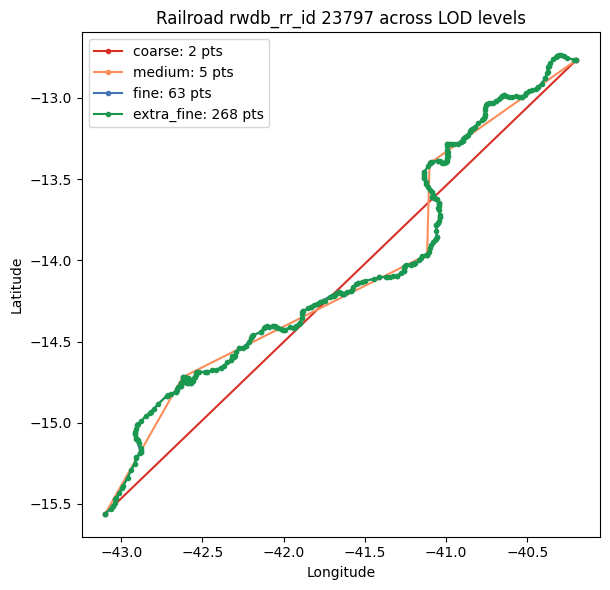

Selected rwdb_rr_id: 23797
Appears in all 4 LOD levels


In [9]:
# Find a feature by rwdb_rr_id that exists in all four LOD levels
# Plot it at all four simplification levels

feature_by_level = {
    name: {
        f["properties"]["rwdb_rr_id"]: f
        for f in fc["features"]
    }
    for name, fc in lod_data.items()
}

common_ids = set.intersection(*(set(features_by_id) for features_by_id in feature_by_level.values()))

# Pick a common feature with many extra-fine points so simplification differences are visible.
selected_id = max(
    common_ids,
    key=lambda rr_id: len(feature_by_level["extra_fine"][rr_id]["geometry"]["coordinates"]),
)

fig, ax = plt.subplots(figsize=(9, 6))
colors = {
    "coarse": "#d73027",
    "medium": "#fc8d59",
    "fine": "#4575b4",
    "extra_fine": "#1a9850",
}

for name in lod_files:
    coords = feature_by_level[name][selected_id]["geometry"]["coordinates"]
    xs = [coord[0] for coord in coords]
    ys = [coord[1] for coord in coords]
    ax.plot(xs, ys, marker="o", markersize=3, linewidth=1.5, color=colors[name], label=f"{name}: {len(coords)} pts")

ax.set_title(f"Railroad rwdb_rr_id {selected_id} across LOD levels")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Selected rwdb_rr_id: {selected_id}")
print(f"Appears in all {len(lod_files)} LOD levels")

## Exercise B

Calculate the **compression ratio** for each LOD level — the ratio of original coordinate count to simplified coordinate count for the features they share.

Then answer: which level gives the best size reduction per unit of visual quality loss?

In [10]:
# Calculate compression ratio per LOD level

original_by_id = {
    f["properties"]["rwdb_rr_id"]: f
    for f in original["features"]
}

print(f"{'Level':<12} {'Shared':>8} {'Original pts':>13} {'LOD pts':>10} {'Ratio':>8} {'Size MB':>9}")
print("-" * 68)

for name, filename in lod_files.items():
    lod_by_id = feature_by_level[name]
    shared_ids = set(original_by_id) & set(lod_by_id)

    original_pts = sum(len(original_by_id[rr_id]["geometry"]["coordinates"]) for rr_id in shared_ids)
    lod_pts = sum(len(lod_by_id[rr_id]["geometry"]["coordinates"]) for rr_id in shared_ids)
    ratio = original_pts / lod_pts
    size_mb = (lod_dir / filename).stat().st_size / 1_000_000

    print(f"{name:<12} {len(shared_ids):>8,} {original_pts:>13,} {lod_pts:>10,} {ratio:>8.2f} {size_mb:>9.2f}")

# Conclusion: medium is the best practical tradeoff here. Coarse has the biggest
# reduction, but it drops many features and visibly distorts lines. Medium keeps
# all features while still cutting far more points and file size than fine or extra_fine.

Level          Shared  Original pts    LOD pts    Ratio   Size MB
--------------------------------------------------------------------
coarse          2,845       230,792      5,690    40.56      1.08
medium         25,408     1,395,426     55,494    25.15      9.66
fine           25,408     1,395,426    124,795    11.18     11.34
extra_fine     25,408     1,395,426    441,580     3.16     18.98


## Check Your Understanding

The coarse level has far fewer features than the other levels because of the `scalerank <= 4` filter.

If a user zooms into a region that has no coarse-level features (e.g. a small country whose railroads are all scalerank 5+), what will they see? And what does this tell us about a limitation of the simple scalerank filter approach?

Write a 2–3 sentence answer.

They will see little or no railroad data in that region until the map switches to a more detailed LOD. This shows that a simple global `scalerank <= 4` filter can remove locally important features, even if those features are not globally important. A better approach would combine scalerank with viewport, zoom, and local density so every region keeps enough useful detail.

---

## Next

In [Module 03 — Bounding Box Culling](../03-Bounding_Box_Culling/README.md), we add viewport filtering — so we only render the features the user can actually see.